<a href="https://colab.research.google.com/github/Sivanunna/Logicmojo-AI-ML-Sept25--siva-/blob/main/Decsion_tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [58]:
import numpy as np
import pandas as pd
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [59]:
import warnings
warnings.filterwarnings('ignore')

In [60]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/drug200.csv')
df

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY
...,...,...,...,...,...,...
195,56,F,LOW,HIGH,11.567,drugC
196,16,M,LOW,HIGH,12.006,drugC
197,52,M,NORMAL,HIGH,9.894,drugX
198,23,M,NORMAL,NORMAL,14.020,drugX


In [61]:
df.isnull().sum()

,0
Age,0
Sex,0
BP,0
Cholesterol,0
Na_to_K,0
Drug,0


<Axes: xlabel='Drug', ylabel='count'>

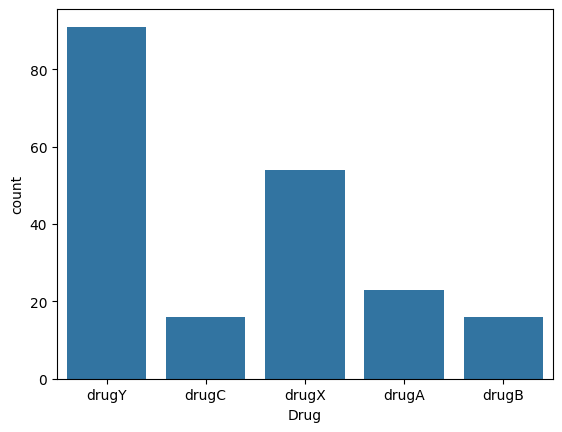

In [62]:
sns.countplot(data=df,x='Drug')

<Axes: xlabel='Cholesterol', ylabel='Age'>

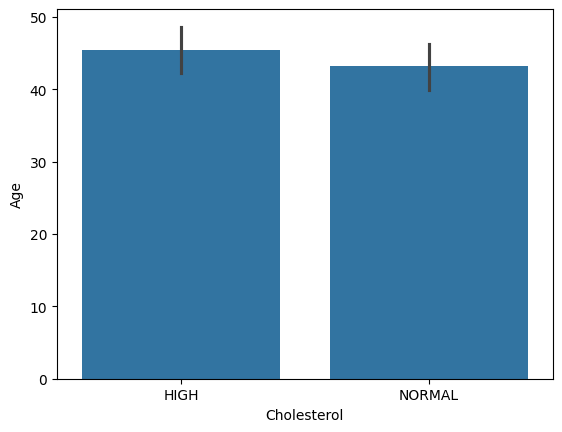

In [63]:
sns.barplot(x='Cholesterol',y='Age',data=df)

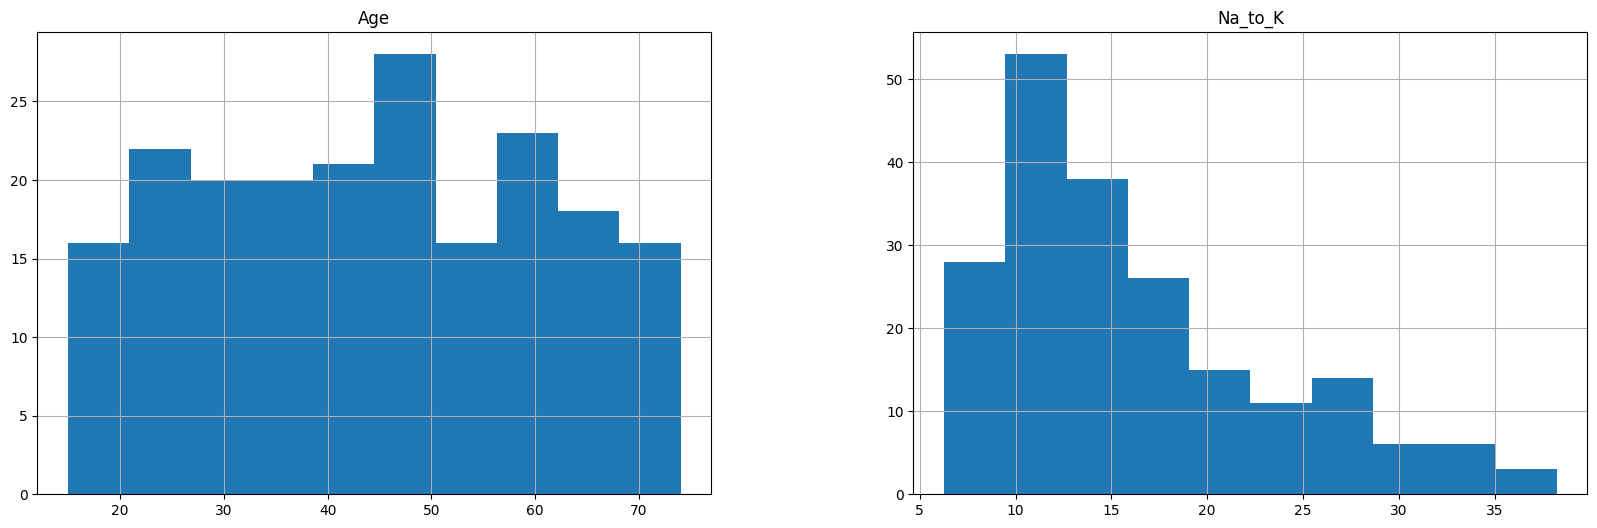

In [64]:
df.hist(figsize=(20, 6))  # Setting the figure size to (20, 20) for better visualization
plt.show()

In [65]:
df = pd.get_dummies(df, columns = ['Sex', 'BP', 'Cholesterol'], drop_first = True)

In [66]:
df

,Age,Na_to_K,Drug,Sex_M,BP_LOW,BP_NORMAL,Cholesterol_NORMAL
0,23,25.355,drugY,False,False,False,False
1,47,13.093,drugC,True,True,False,False
2,47,10.114,drugC,True,True,False,False
3,28,7.798,drugX,False,False,True,False
4,61,18.043,drugY,False,True,False,False
...,...,...,...,...,...,...,...
195,56,11.567,drugC,False,True,False,False
196,16,12.006,drugC,True,True,False,False
197,52,9.894,drugX,True,False,True,False
198,23,14.020,drugX,True,False,True,True


In [67]:
y = df['Drug']
x = df.drop('Drug',axis=1)

In [68]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [69]:
x_train

,Age,Na_to_K,Sex_M,BP_LOW,BP_NORMAL,Cholesterol_NORMAL
79,32,10.840,False,True,False,True
197,52,9.894,True,False,True,False
38,39,9.709,False,False,True,True
24,33,33.486,False,True,False,False
122,34,22.456,True,False,True,False
...,...,...,...,...,...,...
106,22,11.953,True,False,True,False
14,50,12.703,False,False,True,False
92,29,29.450,False,False,False,False
179,67,15.891,False,False,True,False


In [70]:
bool_cols = df.select_dtypes(include='bool')

In [71]:
bool_cols

,Sex_M,BP_LOW,BP_NORMAL,Cholesterol_NORMAL
0,False,False,False,False
1,True,True,False,False
2,True,True,False,False
3,False,False,True,False
4,False,True,False,False
...,...,...,...,...
195,False,True,False,False
196,True,True,False,False
197,True,False,True,False
198,True,False,True,True


In [72]:
bool_col = bool_cols.astype(int)

In [73]:
bool_col

,Sex_M,BP_LOW,BP_NORMAL,Cholesterol_NORMAL
0,0,0,0,0
1,1,1,0,0
2,1,1,0,0
3,0,0,1,0
4,0,1,0,0
...,...,...,...,...
195,0,1,0,0
196,1,1,0,0
197,1,0,1,0
198,1,0,1,1


In [74]:
numcol = df.select_dtypes(include='number')

In [75]:
finaldf = pd.concat([numcol,bool_col],axis=1)

In [76]:
finaldf

,Age,Na_to_K,Sex_M,BP_LOW,BP_NORMAL,Cholesterol_NORMAL
0,23,25.355,0,0,0,0
1,47,13.093,1,1,0,0
2,47,10.114,1,1,0,0
3,28,7.798,0,0,1,0
4,61,18.043,0,1,0,0
...,...,...,...,...,...,...
195,56,11.567,0,1,0,0
196,16,12.006,1,1,0,0
197,52,9.894,1,0,1,0
198,23,14.020,1,0,1,1


In [77]:
y.value_counts(normalize=True)

,proportion
Drug,
drugY,0.455
drugX,0.270
drugA,0.115
drugC,0.080
drugB,0.080


In [78]:
from IPython.display import Image
from io import StringIO
from sklearn.tree import export_graphviz
import pydot


In [79]:
from sklearn.tree import DecisionTreeClassifier

In [80]:
tree_clf = DecisionTreeClassifier(random_state=1)

In [89]:
features = list(finaldf.columns)

In [90]:
tree_clf = tree_clf.fit(finaldf, y)

In [91]:
dot_data = StringIO()

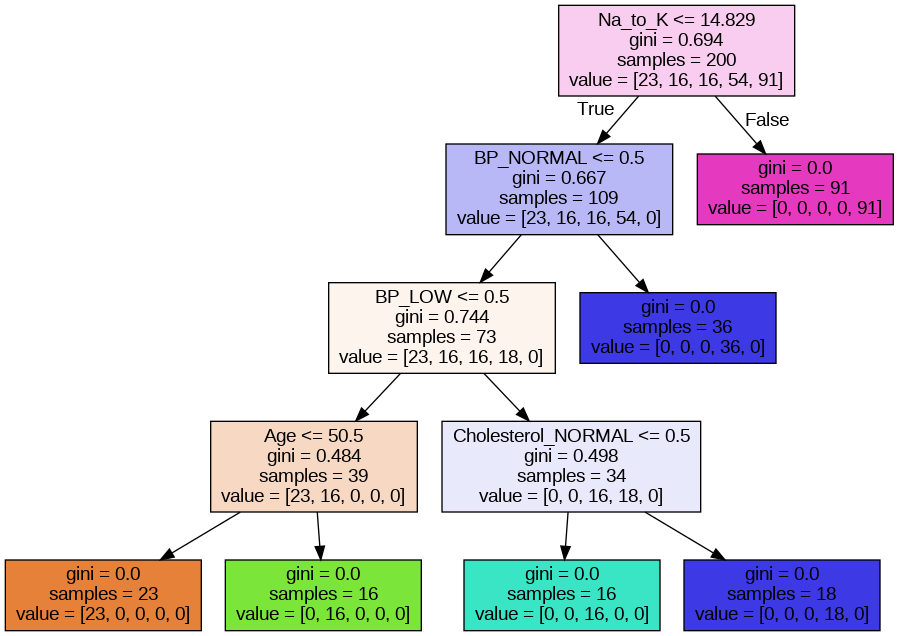

In [92]:
export_graphviz(tree_clf, out_file=dot_data, feature_names=features, filled=True)

# Create a graph from the graphviz data stored in the StringIO object
graph = pydot.graph_from_dot_data(dot_data.getvalue())

# Display the decision tree visualization as an image
Image(graph[0].create_png())

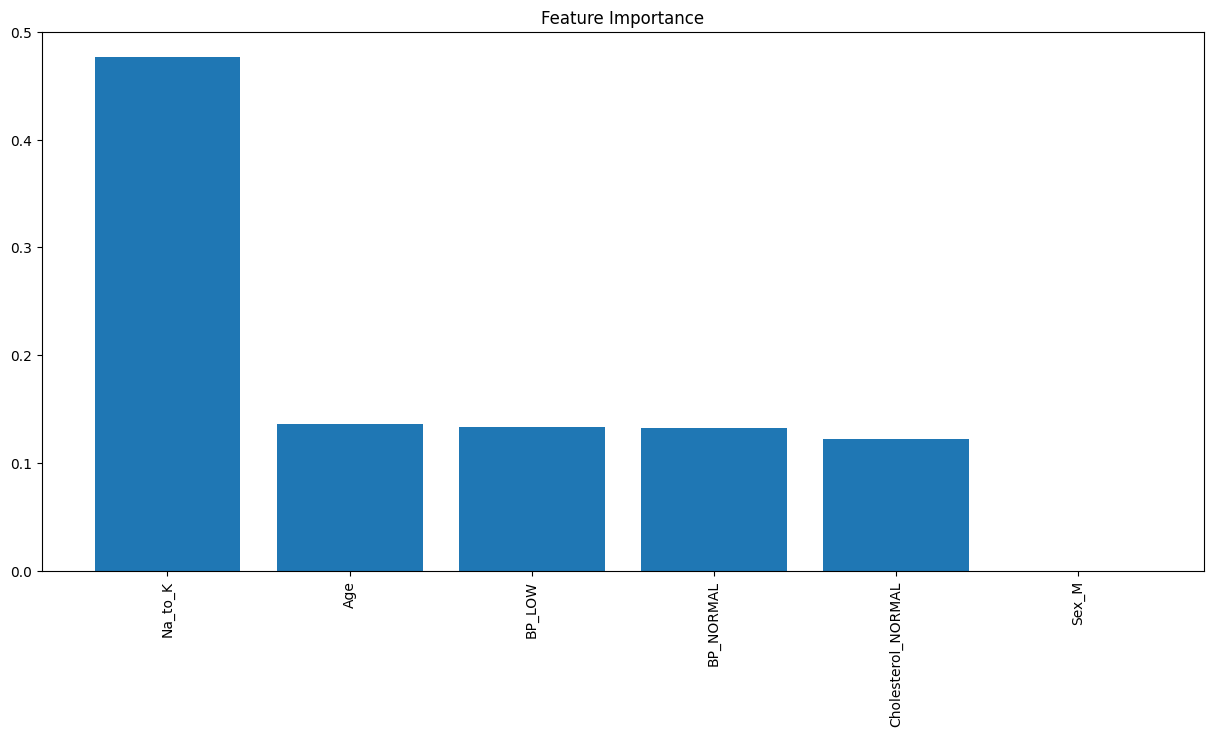

In [93]:
importances = tree_clf.feature_importances_
indices = np.argsort(importances)[::-1]  # Sort feature importances in descending order
names = [features[i] for i in indices]   # Rearrange feature names so they match the sorted feature importances

plt.figure(figsize=(15, 7))  # Create plot
plt.title("Feature Importance")  # Create plot title
plt.bar(range(len(features)), importances[indices])  # Add bars
plt.xticks(range(len(features)), names, rotation=90)  # Add feature names as x-axis labels
plt.show()  # Show plot

In [94]:
pred = tree_clf.predict(x_test)

In [95]:
from sklearn.metrics import confusion_matrix, classification_report

# Compute and print the confusion matrix
print(confusion_matrix(y_test, pred))

# Compute and print the classification report
print(classification_report(y_test, pred))

[[ 6  0  0  0  0]
 [ 0  3  0  0  0]
 [ 0  0  5  0  0]
 [ 0  0  0 11  0]
 [ 0  0  0  0 15]]
              precision    recall  f1-score   support

       drugA       1.00      1.00      1.00         6
       drugB       1.00      1.00      1.00         3
       drugC       1.00      1.00      1.00         5
       drugX       1.00      1.00      1.00        11
       drugY       1.00      1.00      1.00        15

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40

